In [127]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [74]:
df = pd.read_csv("loan_approval_data.csv")
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [75]:
df.shape

(1000, 20)

In [76]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [78]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

# Handling missing values
## numerical :- 
            ex: age = mean 
## categorical :- 
            ex:- gender = most_frequent


In [79]:
categorical_col = df.select_dtypes(include = ['object']).columns
numerical_col = df.select_dtypes(include = ['number']).columns
categorical_col
numerical_col

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [80]:
from sklearn.impute import SimpleImputer
cat_imp = SimpleImputer(strategy='most_frequent')
df[categorical_col] = cat_imp.fit_transform(df[categorical_col])

num_imp = SimpleImputer(strategy='mean')
df[numerical_col] = cat_imp.fit_transform(df[numerical_col])


In [81]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [82]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA


([<matplotlib.patches.Wedge at 0x1ee78d82210>,
 [Text(-0.6521425375337495, 0.8858386482531919, 'NO'),
  Text(0.6521428261765839, -0.8858384357581341, 'YES')],
 [Text(-0.3557141113820451, 0.48318471722901374, '70.2%'),
  Text(0.3557142688235912, -0.4831846013226186, '29.8%')])

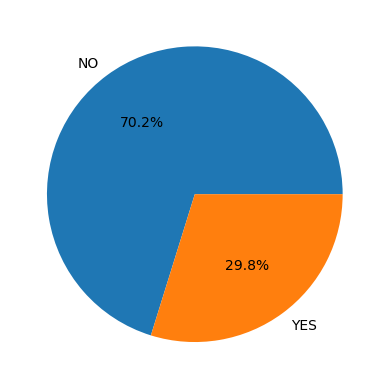

In [83]:
#how our data is balance
class_count = df['Loan_Approved'].value_counts()
plt.pie(class_count, labels=["NO","YES"],autopct='%1.1f%%')

[Text(0, 0, '621'), Text(0, 0, '379')]

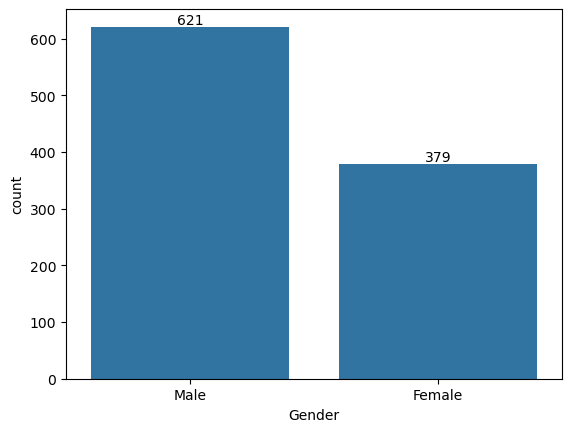

In [84]:
#analise categorical variables
gender_count = df['Gender'].value_counts()
axi = sns.barplot(gender_count)
axi.bar_label(axi.containers[0])

[Text(0, 0, '515'), Text(0, 0, '213'), Text(0, 0, '182'), Text(0, 0, '90')]

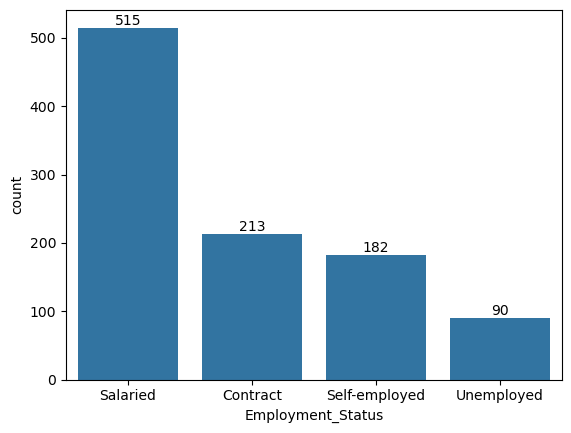

In [85]:
eEmployment_Status_count = df['Employment_Status'].value_counts()
axi = sns.barplot(eEmployment_Status_count)
axi.bar_label(axi.containers[0])

[Text(0, 0, '643'), Text(0, 0, '357')]

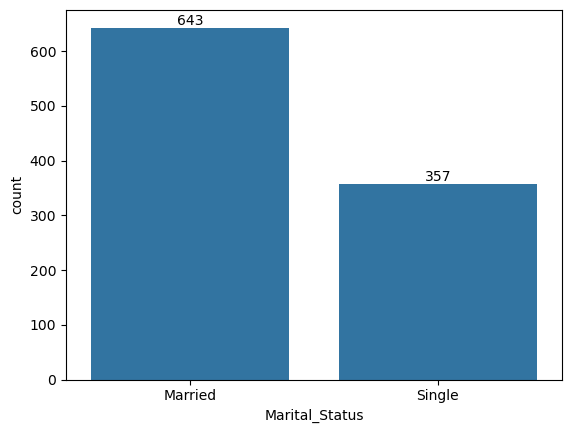

In [86]:
Marital_Status_count = df['Marital_Status'].value_counts()
axi = sns.barplot(Marital_Status_count)
axi.bar_label(axi.containers[0])

[Text(0, 0, '252'),
 Text(0, 0, '199'),
 Text(0, 0, '190'),
 Text(0, 0, '181'),
 Text(0, 0, '178')]

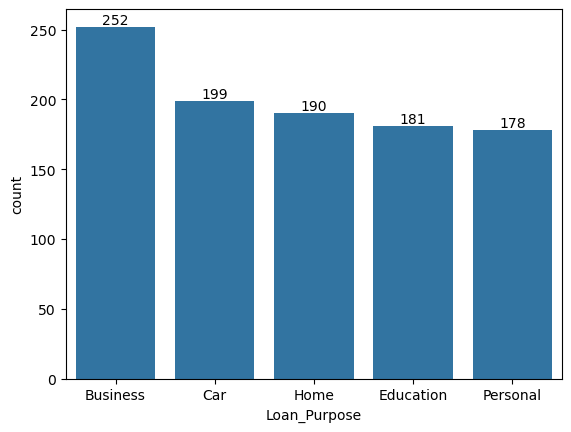

In [87]:
Loan_Purpose_count = df['Loan_Purpose'].value_counts()
axi = sns.barplot(Loan_Purpose_count)
axi.bar_label(axi.containers[0])

[Text(0, 0, '517'), Text(0, 0, '294'), Text(0, 0, '189')]

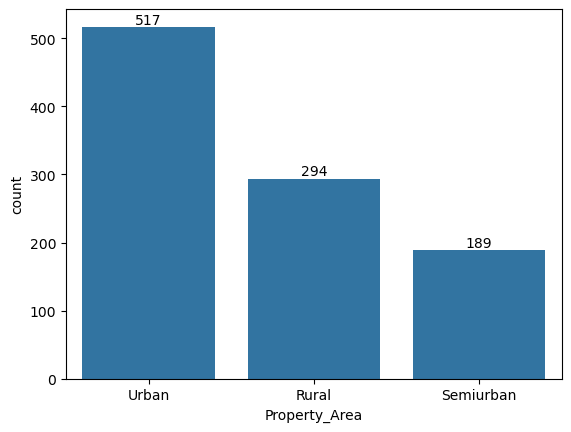

In [88]:
Property_Area_count = df['Property_Area'].value_counts()
axi = sns.barplot(Property_Area_count)
axi.bar_label(axi.containers[0])

[Text(0, 0, '722'), Text(0, 0, '278')]

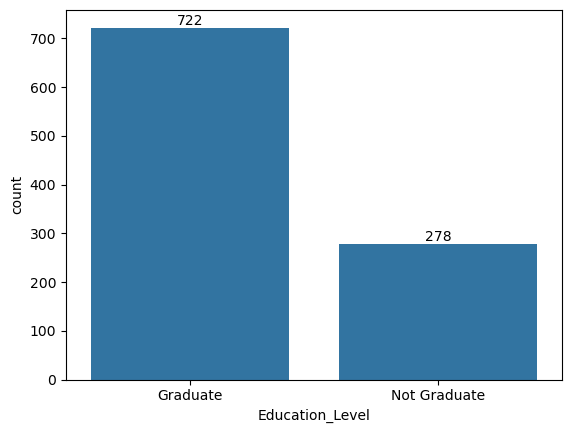

In [89]:
Education_Level_count = df['Education_Level'].value_counts()
axi = sns.barplot(Education_Level_count)
axi.bar_label(axi.containers[0])

[Text(0, 0, '422'),
 Text(0, 0, '202'),
 Text(0, 0, '144'),
 Text(0, 0, '135'),
 Text(0, 0, '97')]

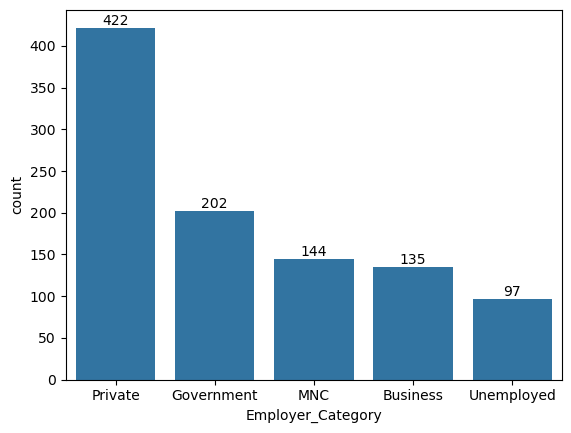

In [90]:
Employer_Category_count = df['Employer_Category'].value_counts()
axi = sns.barplot(Employer_Category_count)
axi.bar_label(axi.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

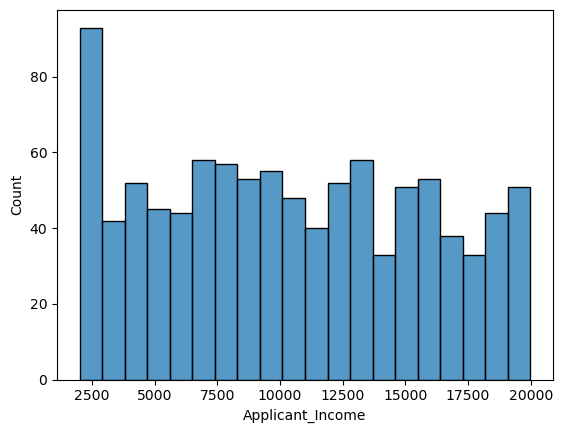

In [91]:
# analyse income
sns.histplot(
    data = df,
    x = 'Applicant_Income',
    bins = 20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

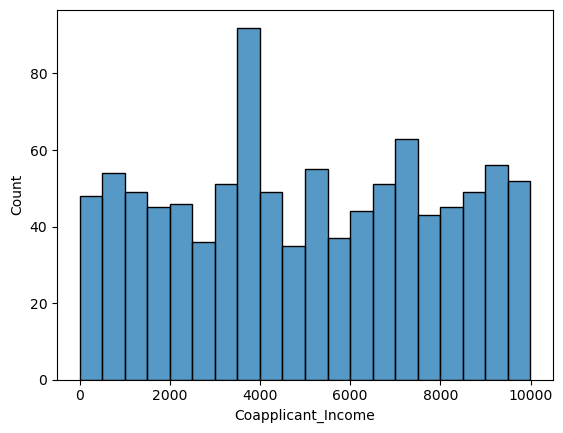

In [92]:
sns.histplot(
    data = df,
    x = 'Coapplicant_Income',
    bins = 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

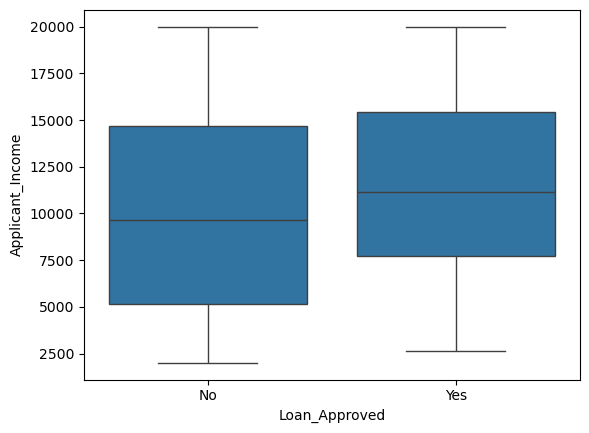

In [93]:
#outliers - boxplot
sns.boxplot(
    data = df,
    x = 'Loan_Approved',
    y = 'Applicant_Income'
)

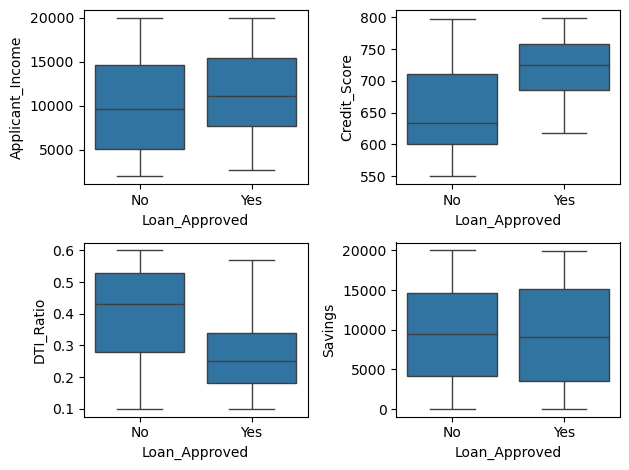

In [94]:
fig , axes = plt.subplots(2,2)
sns.boxplot(ax = axes[0,0],data = df,x = 'Loan_Approved',y = 'Applicant_Income')
sns.boxplot(ax = axes[0,1],data = df,x = 'Loan_Approved',y = 'Credit_Score')
sns.boxplot(ax = axes[1,0],data = df,x = 'Loan_Approved',y = 'DTI_Ratio')
sns.boxplot(ax = axes[1,1],data = df,x = 'Loan_Approved',y = 'Savings')
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

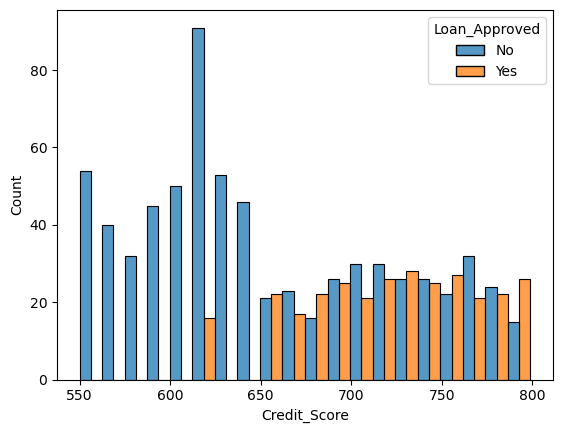

In [95]:
# Credit score with loan approved
sns.histplot(
    data = df,
    x = 'Credit_Score',
    hue = 'Loan_Approved',
    bins = 20,
    multiple = 'dodge'
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

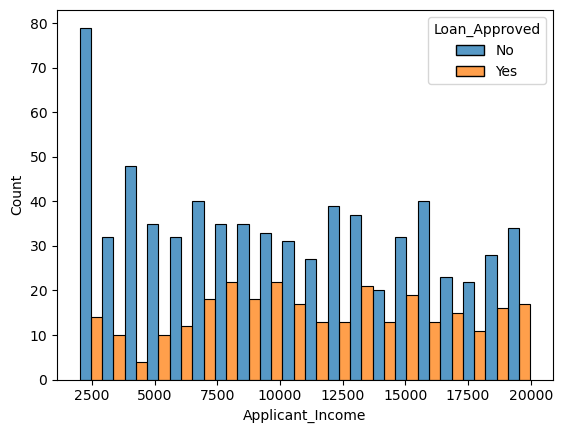

In [96]:
sns.histplot(
    data = df,
    x = 'Applicant_Income',
    hue = 'Loan_Approved',
    bins = 20,
    multiple = 'dodge'
)

In [97]:
# remove applicant id
df = df.drop('Applicant_ID',axis=1)
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2728.0,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,1883.0,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


# Encoding

In [98]:
df.head()
df.columns

Index(['Applicant_Income', 'Coapplicant_Income', 'Employment_Status', 'Age',
       'Marital_Status', 'Dependents', 'Credit_Score', 'Existing_Loans',
       'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term',
       'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender',
       'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [99]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder 
le = LabelEncoder()
df['Education_Level'] = le.fit_transform(df['Education_Level'])
df['Loan_Approved'] = le.fit_transform(df['Loan_Approved'])

df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [100]:
col = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
ohe = OneHotEncoder(drop='first',sparse_output = False,handle_unknown='ignore')
encoded = ohe.fit_transform(df[col])

encoded_df = pd.DataFrame(encoded , columns = ohe.get_feature_names_out(col), index = df.index)

df = pd.concat([df.drop(columns=col),encoded_df],axis=1)

In [103]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Correlation Heatmap

<Axes: >

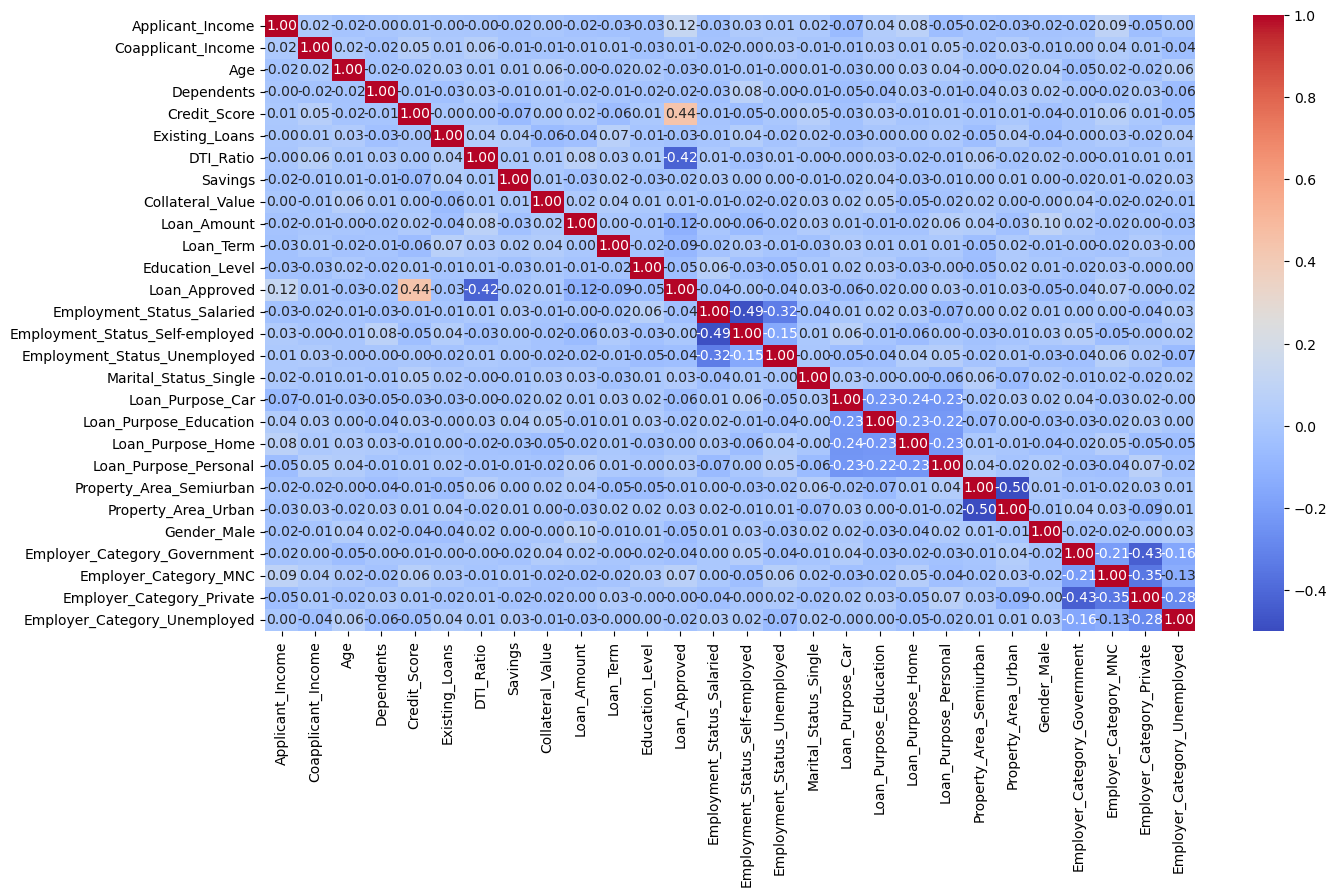

In [107]:
num_cols = df.select_dtypes(include = 'number')
corr_matrix = num_cols.corr()
plt.figure(figsize =(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [105]:
num_cols.corr()['Loan_Approved'].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.441910
Applicant_Income                   0.122579
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.012891
Coapplicant_Income                 0.007439
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.016087
Loan_Purpose_Education            -0.016684
Dependents                        -0.018999
Employer_Category_Unemployed      -0.021468
Age                               -0.025385
Existing_Loans                    -0.028553
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

# Train_Test_Split + Feature Scaling

In [108]:
X = df.drop("Loan_Approved",axis=1)
y = df["Loan_Approved"]

In [109]:
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [111]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [112]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [114]:
X_test_scaled

array([[ 0.47931373,  0.57238878,  1.12666798, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 1.02772701,  0.61119674,  0.13717914, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.5559253 , -0.51735252,  1.03671445, ..., -0.41388776,
         1.16316   , -0.30723158],
       ...,
       [-0.5599048 , -0.0755655 ,  1.21662151, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.27489666, -0.94735854, -0.58244912, ..., -0.41388776,
        -0.85972695, -0.30723158],
       [-0.61315433, -1.21243075,  0.67690032, ..., -0.41388776,
         1.16316   , -0.30723158]])

# Train & Evaluate Models

In [117]:
# logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix ,accuracy_score, precision_score, recall_score, f1_score
lg = LogisticRegression()
lg.fit(X_train_scaled , y_train)
y_pred = lg.predict(X_test_scaled)

#Evaluation
print("LogisticRegression Model")
print("precision:", precision_score(y_test,y_pred))
print("recall:", recall_score(y_test,y_pred))
print("f1:", f1_score(y_test,y_pred))
print("accuracy:", accuracy_score(y_test,y_pred))
print("confusion_matrix:", confusion_matrix(y_test,y_pred))


LogisticRegression Model
precision: 0.8214285714285714
recall: 0.7540983606557377
f1: 0.7863247863247863
accuracy: 0.875
confusion_matrix: [[129  10]
 [ 15  46]]


In [124]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled , y_train)
y_pred = knn.predict(X_test_scaled)

#Evaluation
print("KNN Model")
print("precision:", precision_score(y_test,y_pred))
print("recall:", recall_score(y_test,y_pred))
print("f1:", f1_score(y_test,y_pred))
print("accuracy:", accuracy_score(y_test,y_pred))
print("confusion_matrix:", confusion_matrix(y_test,y_pred))

KNN Model
precision: 0.6216216216216216
recall: 0.3770491803278688
f1: 0.46938775510204084
accuracy: 0.74
confusion_matrix: [[125  14]
 [ 38  23]]


In [125]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train_scaled , y_train)
y_pred = gnb.predict(X_test_scaled)

#Evaluation
print("Naive Bayes Model")
print("precision:", precision_score(y_test,y_pred))
print("recall:", recall_score(y_test,y_pred))
print("f1:", f1_score(y_test,y_pred))
print("accuracy:", accuracy_score(y_test,y_pred))
print("confusion_matrix:", confusion_matrix(y_test,y_pred))

Naive Bayes Model
precision: 0.8627450980392157
recall: 0.7213114754098361
f1: 0.7857142857142857
accuracy: 0.88
confusion_matrix: [[132   7]
 [ 17  44]]


## best model is = Naive Bayes 

# Feature Engineering

In [129]:
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2
# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = df.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio"])
y = df["Loan_Approved"]

# train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [130]:
# logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix ,accuracy_score, precision_score, recall_score, f1_score
lg = LogisticRegression()
lg.fit(X_train_scaled , y_train)
y_pred = lg.predict(X_test_scaled)

#Evaluation
print("LogisticRegression Model")
print("precision:", precision_score(y_test,y_pred))
print("recall:", recall_score(y_test,y_pred))
print("f1:", f1_score(y_test,y_pred))
print("accuracy:", accuracy_score(y_test,y_pred))
print("confusion_matrix:", confusion_matrix(y_test,y_pred))


LogisticRegression Model
precision: 0.8392857142857143
recall: 0.7704918032786885
f1: 0.8034188034188035
accuracy: 0.885
confusion_matrix: [[130   9]
 [ 14  47]]


In [131]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled , y_train)
y_pred = knn.predict(X_test_scaled)

#Evaluation
print("KNN Model")
print("precision:", precision_score(y_test,y_pred))
print("recall:", recall_score(y_test,y_pred))
print("f1:", f1_score(y_test,y_pred))
print("accuracy:", accuracy_score(y_test,y_pred))
print("confusion_matrix:", confusion_matrix(y_test,y_pred))

KNN Model
precision: 0.6666666666666666
recall: 0.45901639344262296
f1: 0.5436893203883495
accuracy: 0.765
confusion_matrix: [[125  14]
 [ 33  28]]


In [132]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train_scaled , y_train)
y_pred = gnb.predict(X_test_scaled)

#Evaluation
print("Naive Bayes Model")
print("precision:", precision_score(y_test,y_pred))
print("recall:", recall_score(y_test,y_pred))
print("f1:", f1_score(y_test,y_pred))
print("accuracy:", accuracy_score(y_test,y_pred))
print("confusion_matrix:", confusion_matrix(y_test,y_pred))

Naive Bayes Model
precision: 0.8235294117647058
recall: 0.6885245901639344
f1: 0.75
accuracy: 0.86
confusion_matrix: [[130   9]
 [ 19  42]]


## our best model is now is logistic regression 